In [1]:
import os
import zipfile
import json
import pandas as pd
from tqdm import tqdm

# ✅ ① 압축파일이 들어있는 상위 폴더 경로 지정
base_dir = r"C:\\Users\\user\\Downloads\\046.공감형 대화\\01-1.정식개방데이터\\Validation\\02.라벨링데이터"  

# ✅ ② 압축 해제 폴더 지정
extract_dir = os.path.join(base_dir, "unzipped")
os.makedirs(extract_dir, exist_ok=True)

# ✅ ③ ZIP 파일 전체 해제
for zip_name in tqdm(os.listdir(base_dir)):
    if zip_name.endswith(".zip"):
        zip_path = os.path.join(base_dir, zip_name)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

print("✅ 모든 ZIP 파일 압축 해제 완료!")

# ✅ ④ JSON 파일 전체 탐색 및 통합
all_data = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".json"):
            with open(os.path.join(root, file), "r", encoding="utf-8") as f:
                data = json.load(f)
                all_data.append(data)

print(f"📁 총 {len(all_data)}개의 JSON 파일 로드 완료!")

100%|██████████| 44/44 [00:00<00:00, 57.61it/s]


✅ 모든 ZIP 파일 압축 해제 완료!
📁 총 3182개의 JSON 파일 로드 완료!


In [5]:
# utterances를 풀어서 하나의 DataFrame으로 통합
rows = []

for data in tqdm(all_data):
    info = data.get("info", {})
    utterances = data.get("utterances", [])

    for u in utterances:
        row = {
            "dialogue_id": info.get("id"),
            "category": info.get("category"),
            "relation": info.get("relation"),
            "situation": info.get("situation"),
            "speaker_emotion": info.get("speaker_emotion"),
            "role": u.get("role"),
            "text": u.get("text"),
            "listener_empathy": u.get("listener_empathy"),
            "terminate": u.get("terminate")
        }
        rows.append(row)

df = pd.DataFrame(rows)
print(f"✅ 최종 DataFrame 크기: {df.shape}")
df.head()

  0%|          | 0/25456 [00:00<?, ?it/s]

100%|██████████| 25456/25456 [00:00<00:00, 64488.97it/s] 


✅ 최종 DataFrame 크기: (378563, 9)


,dialogue_id,category,relation,situation,speaker_emotion,role,text,listener_empathy,terminate
0,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,"엄마, 아기가 태어나니까 내가 부모로서 해야 할 게 참 많은 것 같아요.",None,False
1,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,그렇지? 아기 키우는 게 여간 어려운 일이 아니야.,[위로],False
2,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,어제 평소보다도 격하게 막 온몸을 써가면서 울더라고요. 얼마나 당황했는지 몰라요.,None,False
3,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,배가 고파서 그랬던 것 아닐까? 아기들은 배가 고프면 몸부림을 친단다.,None,False
4,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,맞아요. 젖을 물려주니 금세 뚝 그쳤어요. 난 분명히 순했을 것 같은데.,None,False


In [4]:
# ✅ ① 압축파일이 들어있는 상위 폴더 경로 지정
base_dir = r"C:\\Users\\user\\Downloads\\046.공감형 대화\\01-1.정식개방데이터\\Training\\02.라벨링데이터"  

# ✅ ② 압축 해제 폴더 지정
extract_dir = os.path.join(base_dir, "unzipped")
os.makedirs(extract_dir, exist_ok=True)

# ✅ ③ ZIP 파일 전체 해제
for zip_name in tqdm(os.listdir(base_dir)):
    if zip_name.endswith(".zip"):
        zip_path = os.path.join(base_dir, zip_name)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

print("✅ 모든 ZIP 파일 압축 해제 완료!")

# ✅ ④ JSON 파일 전체 탐색 및 통합
all_data = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".json"):
            with open(os.path.join(root, file), "r", encoding="utf-8") as f:
                data = json.load(f)
                all_data.append(data)

print(f"📁 총 {len(all_data)}개의 JSON 파일 로드 완료!")

100%|██████████| 43/43 [00:05<00:00,  7.36it/s]


✅ 모든 ZIP 파일 압축 해제 완료!
📁 총 25456개의 JSON 파일 로드 완료!


In [7]:
# utterances를 풀어서 하나의 DataFrame으로 통합
rows = []

for data in tqdm(all_data):
    info = data.get("info", {})
    utterances = data.get("utterances", [])

    for u in utterances:
        row = {
            "dialogue_id": info.get("id"),
            "category": info.get("category"),
            "relation": info.get("relation"),
            "situation": info.get("situation"),
            "speaker_emotion": info.get("speaker_emotion"),
            "role": u.get("role"),
            "text": u.get("text"),
            "listener_empathy": u.get("listener_empathy"),
            "terminate": u.get("terminate")
        }
        rows.append(row)

df2 = pd.DataFrame(rows)
print(f"✅ 최종 DataFrame 크기: {df2.shape}")
df2.head()

100%|██████████| 25456/25456 [00:00<00:00, 58719.02it/s] 

✅ 최종 DataFrame 크기: (378563, 9)


,dialogue_id,category,relation,situation,speaker_emotion,role,text,listener_empathy,terminate
0,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,"엄마, 아기가 태어나니까 내가 부모로서 해야 할 게 참 많은 것 같아요.",None,False
1,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,그렇지? 아기 키우는 게 여간 어려운 일이 아니야.,[위로],False
2,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,어제 평소보다도 격하게 막 온몸을 써가면서 울더라고요. 얼마나 당황했는지 몰라요.,None,False
3,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,배가 고파서 그랬던 것 아닐까? 아기들은 배가 고프면 몸부림을 친단다.,None,False
4,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,맞아요. 젖을 물려주니 금세 뚝 그쳤어요. 난 분명히 순했을 것 같은데.,None,False


In [8]:
df_all = pd.concat([df, df2], ignore_index=True)
print(f"통합 데이터 크기: {df_all.shape}")
df_all.head()

통합 데이터 크기: (757126, 9)


,dialogue_id,category,relation,situation,speaker_emotion,role,text,listener_empathy,terminate
0,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,"엄마, 아기가 태어나니까 내가 부모로서 해야 할 게 참 많은 것 같아요.",None,False
1,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,그렇지? 아기 키우는 게 여간 어려운 일이 아니야.,[위로],False
2,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,어제 평소보다도 격하게 막 온몸을 써가면서 울더라고요. 얼마나 당황했는지 몰라요.,None,False
3,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,배가 고파서 그랬던 것 아닐까? 아기들은 배가 고프면 몸부림을 친단다.,None,False
4,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,맞아요. 젖을 물려주니 금세 뚝 그쳤어요. 난 분명히 순했을 것 같은데.,None,False


In [ ]:
# !pip install konlpy

  Using cached konlpy-0.6.0-py2.py3-none-any.whl.metadata (1.9 kB)
Using cached konlpy-0.6.0-py2.py3-none-any.whl (19.4 MB)


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from konlpy.tag import Okt

In [10]:
# Matplotlib 한글 폰트 설정 (필요에 따라 폰트 경로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 사용자
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 사용자
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [11]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757126 entries, 0 to 757125
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   dialogue_id       757126 non-null  object
 1   category          757126 non-null  object
 2   relation          757126 non-null  object
 3   situation         757126 non-null  object
 4   speaker_emotion   757126 non-null  object
 5   role              757126 non-null  object
 6   text              757126 non-null  object
 7   listener_empathy  290712 non-null  object
 8   terminate         757126 non-null  bool  
dtypes: bool(1), object(8)
memory usage: 46.9+ MB


In [12]:
df_all['category'].unique()

array(['공감형 대화'], dtype=object)

In [13]:
df_all['category'].value_counts()

category
공감형 대화    757126
Name: count, dtype: int64

In [14]:
df_all['role'].unique()

array(['speaker', 'listener'], dtype=object)

In [15]:
df_all['role'].value_counts()

role
speaker     393522
listener    363604
Name: count, dtype: int64

In [16]:
df_all['speaker_emotion'].unique()

array(['기쁨', '당황', '분노', '불안', '상처', '슬픔'], dtype=object)

In [17]:
df_all['speaker_emotion'].value_counts()

speaker_emotion
분노    153130
기쁨    147536
슬픔    115316
불안    115294
당황    113222
상처    112628
Name: count, dtype: int64

In [ ]:
df_all['listener_empathy'].unique()

TypeError: unhashable type: 'list'

In [18]:
print(df_all['listener_empathy'].astype(str).unique())

['None' "['위로']" "['격려']" "['조언', '격려']" "['동조']" "['위로', '동조']" "['조언']"
 "['조언', '동조']" "['격려', '동조']" "['격려', '위로']" "['격려', '위로', '동조']"
 "['조언', '격려', '동조']" "['조언', '위로']" "['조언', '위로', '동조']"
 "['조언', '격려', '위로']" "['조언', '격려', '위로', '동조']" "['동조', '격려']"
 "['격려', '조언']" "['동조', '조언']" "['동조', '위로']" "['격려', '동조', '위로']"
 "['동조', '조언', '위로']" "['동조', '격려', '위로']" "['격려', '동조', '조언']"
 "['동조', '격려', '조언']" "['격려', '조언', '위로']"]


In [19]:
print(df_all['listener_empathy'].astype(str).value_counts())

listener_empathy
None                        466414
['동조']                       49016
['위로', '동조']                 36654
['격려']                       35396
['위로']                       32622
['격려', '동조']                 29948
['조언']                       25888
['조언', '격려']                 20238
['조언', '동조']                 18304
['조언', '위로']                 15998
['격려', '위로']                  8074
['조언', '격려', '동조']            5052
['조언', '위로', '동조']            5006
['조언', '격려', '위로']            3846
['격려', '위로', '동조']            3140
['동조', '격려']                  1004
['격려', '조언']                   154
['동조', '조언']                   138
['동조', '위로']                   122
['조언', '격려', '위로', '동조']        36
['동조', '격려', '위로']              22
['격려', '동조', '위로']              14
['동조', '조언', '위로']              12
['격려', '동조', '조언']              10
['동조', '격려', '조언']              10
['격려', '조언', '위로']               8
Name: count, dtype: int64


In [20]:
df_all['terminate'].unique()

array([False,  True])

In [21]:
df_all['terminate'].value_counts()

terminate
False    706214
True      50912
Name: count, dtype: int64

In [22]:
df_all['terminate'].head(20)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17    False
18    False
19    False
Name: terminate, dtype: bool

In [23]:
df_all['situation'].unique()

array(['아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.', '동해를 보러 왔다.',
       '엄마에게 뜬금없이 사랑한다는 문자를 받았다.', ..., '4kg를 감량했으나 아무도 못 알아본다.',
       '세월이 흐를수록 사람 사귀는 일은 많은 용기와 노력이 필요했다.',
       '다이어트 중인데 밤10시에 보쌈세트를 주문했다.'], dtype=object)

In [24]:
df_all['situation'].value_counts()

situation
그 일로 직장을 잃었다.                   154
바닷가에 밀려온 쓰레기를 주웠다.              148
성인이 된 후에도 부모님께 어린이날 용돈을 받는다.    146
다이어트에 성공했다.                     146
도서관에서 빌린 책이 찢어졌다.               144
                               ... 
식사하면서 실수로 소주병을 깼다.               28
오늘은 2만보를 걸었다.                    28
벌레가 너무 많아서 민원을 넣었다.              28
제사가 다가오고 있다.                     28
집이 20층인데 퇴근시간에 엘리베이터가 고장이다.      28
Name: count, Length: 16003, dtype: int64

In [28]:
df_all['situation'].dtype

dtype('O')

In [29]:
print(df_all['situation'].head().tolist())

['아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.', '아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.', '아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.', '아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.', '아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.']


In [30]:
print(df_all['listener_empathy'].head().tolist())

[None, ['위로'], None, None, None]


In [31]:
def clean_listener_empathy(item):
    """
    listener_empathy 컬럼의 리스트 형태를 문자열로 변환합니다.
    - ['위로'] -> '위로'
    - None -> 'None' (문자열로 통일)
    """
    if isinstance(item, list):
        # 리스트에 요소가 있으면 첫 번째 요소(문자열)를 반환
        return item[0] if item else 'None'
    # 이미 문자열이거나 NoneType인 경우 그대로 반환 (NoneType은 str('None')으로 변환)
    return str(item)

# listener_empathy 컬럼에 정제 함수 적용
df_all['listener_empathy'] = df_all['listener_empathy'].apply(clean_listener_empathy)

print("--- 정제 후 listener_empathy 컬럼 상위 5개 값 ---")
print(df_all['listener_empathy'].head().tolist())
# 결과는 ['None', '위로', 'None', 'None', 'None']와 유사하게 출력되어야 합니다.

--- 정제 후 listener_empathy 컬럼 상위 5개 값 ---
['None', '위로', 'None', 'None', 'None']


In [25]:
df_all.head(20)

,dialogue_id,category,relation,situation,speaker_emotion,role,text,listener_empathy,terminate
0,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,"엄마, 아기가 태어나니까 내가 부모로서 해야 할 게 참 많은 것 같아요.",None,False
1,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,그렇지? 아기 키우는 게 여간 어려운 일이 아니야.,[위로],False
2,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,어제 평소보다도 격하게 막 온몸을 써가면서 울더라고요. 얼마나 당황했는지 몰라요.,None,False
3,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,배가 고파서 그랬던 것 아닐까? 아기들은 배가 고프면 몸부림을 친단다.,None,False
4,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,맞아요. 젖을 물려주니 금세 뚝 그쳤어요. 난 분명히 순했을 것 같은데.,None,False
5,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,말도 마. 네가 얼마나 까탈스러웠는데. 우리 손주가 내 딸을 빼다 박았네.,None,False
6,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,잠도 못 자고 우는 아이 달래랴 수유하랴 머리카락이 다 빠지는 줄 알았어요.,None,False
7,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,"네가 어른 노릇, 부모 노릇을 하느라 고생이 정말 많구나.",[위로],False
8,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,speaker,그러면서 엄마 생각이 많이 났어요. 엄마는 직장까지 다니면서 나를 키우느라 얼마나 ...,None,False
9,BE22000014,공감형 대화,부모자녀/조손,아이가 태어나니 부모가 배우고 익혀야 할 것이 많다.,기쁨,listener,우리 딸이 엄마가 되더니 철이 들었네. 하지만 네가 웃어주면 세상 모든 시름이 사라...,[격려],False


In [ ]:

# # 1. 시작 감정 (Start Emotion) 추출: 각 대화 세션의 'turn' 컬럼 중 최솟값
# # (일반적으로 turn=0 또는 turn=1)
# start_emotions = df_all.loc[df_all.groupby('dialogue_id')['dialogue_id'].idxmin()].set_index('dialogue_id')['speaker_emotion'].rename('start_emotion')

# # 2. 마지막 감정 (End Emotion) 추출: 각 대화 세션의 'turn' 컬럼 중 최댓값
# end_emotions = df_all.loc[df_all.groupby('dialogue_id')['dialogue_id'].idxmax()].set_index('dialogue_id')['speaker_emotion'].rename('end_emotion')

# # 3. 후속 감정 상태 정의 테이블 생성
# emotion_flow_df = pd.concat([start_emotions, end_emotions], axis=1).reset_index(names='dialogue_session_id')


# # 4. 후속 감정 레이블링 규칙 적용 (이전과 동일)
# # 후속 감정이 '기쁨' 또는 '중립'이 아니면 '미해결'로 간주
# def map_result_emotion(row):
#     # 시작 감정이 '기쁨'인 경우 (유지/강화되어 레이블링 안 됨)
#     if row['start_emotion'] == '기쁨':
#         return '기쁨 유지 (규칙 제외)'
    
#     # 부정적 감정 해소 성공 케이스
#     elif row['end_emotion'] in ['기쁨', '중립']:
#         return row['end_emotion']
    
#     # 부정적 감정 해소 실패/미완료 (마지막에도 부정적 감정 유지)
#     else:
#         # 부정적 감정 해소 실패의 경우, 마지막 감정 이름을 그대로 사용해도 좋습니다.
#         return '미해결' # 또는 row['end_emotion']

# emotion_flow_df['final_result'] = emotion_flow_df.apply(map_result_emotion, axis=1)

# print("--- 감정 흐름 분석 테이블 (Top 5) ---")
# print(emotion_flow_df.head())

--- 감정 흐름 분석 테이블 (Top 5) ---
  dialogue_session_id start_emotion end_emotion   final_result
0          BE22000001            분노          분노            미해결
1          BE22000002            슬픔          슬픔            미해결
2          BE22000003            슬픔          슬픔            미해결
3          BE22000004            기쁨          기쁨  기쁨 유지 (규칙 제외)
4          BE22000005            분노          분노            미해결


In [ ]:
# print(emotion_flow_df.head(20))

   dialogue_session_id start_emotion end_emotion   final_result
0           BE22000001            분노          분노            미해결
1           BE22000002            슬픔          슬픔            미해결
2           BE22000003            슬픔          슬픔            미해결
3           BE22000004            기쁨          기쁨  기쁨 유지 (규칙 제외)
4           BE22000005            분노          분노            미해결
5           BE22000006            분노          분노            미해결
6           BE22000007            슬픔          슬픔            미해결
7           BE22000008            분노          분노            미해결
8           BE22000009            당황          당황            미해결
9           BE22000010            슬픔          슬픔            미해결
10          BE22000011            불안          불안            미해결
11          BE22000012            슬픔          슬픔            미해결
12          BE22000013            기쁨          기쁨  기쁨 유지 (규칙 제외)
13          BE22000014            기쁨          기쁨  기쁨 유지 (규칙 제외)
14          BE22000015            분노    

In [ ]:
# print(emotion_flow_df.tail(20))

      dialogue_session_id start_emotion end_emotion final_result
28618          BE22031638            상처          상처          미해결
28619          BE22031639            상처          상처          미해결
28620          BE22031641            당황          당황          미해결
28621          BE22031642            당황          당황          미해결
28622          BE22031643            당황          당황          미해결
28623          BE22031644            당황          당황          미해결
28624          BE22031645            상처          상처          미해결
28625          BE22031646            상처          상처          미해결
28626          BE22031647            당황          당황          미해결
28627          BE22031648            당황          당황          미해결
28628          BE22031649            당황          당황          미해결
28629          BE22031650            상처          상처          미해결
28630          BE22031651            상처          상처          미해결
28631          BE22031652            상처          상처          미해결
28632          BE22031655

# 감정 및 공감 반응 분포 시각화

C:\Users\user\AppData\Local\Temp\ipykernel_17012\3999747141.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_17012\3999747141.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_17012\3999747141.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i],

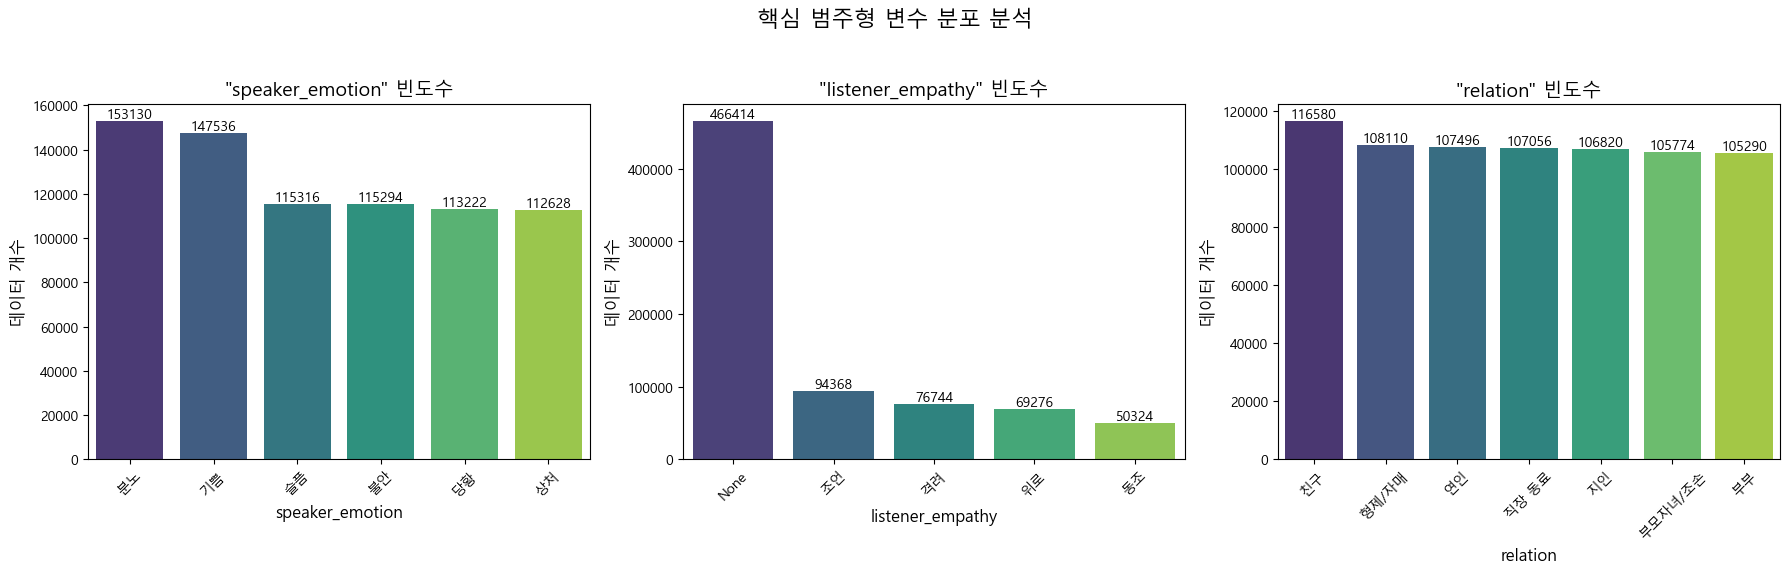


--- speaker_emotion 분포 ---
speaker_emotion
분노    20.23
기쁨    19.49
슬픔    15.23
불안    15.23
당황    14.95
상처    14.88
Name: proportion, dtype: float64

--- listener_empathy 분포 ---
listener_empathy
[동조]                16.86
[위로, 동조]            12.61
[격려]                12.18
[위로]                11.22
[격려, 동조]            10.30
[조언]                 8.91
[조언, 격려]             6.96
[조언, 동조]             6.30
[조언, 위로]             5.50
[격려, 위로]             2.78
[조언, 격려, 동조]         1.74
[조언, 위로, 동조]         1.72
[조언, 격려, 위로]         1.32
[격려, 위로, 동조]         1.08
[동조, 격려]             0.35
[격려, 조언]             0.05
[동조, 조언]             0.05
[동조, 위로]             0.04
[조언, 격려, 위로, 동조]     0.01
[동조, 격려, 위로]         0.01
[격려, 동조, 위로]         0.00
[동조, 조언, 위로]         0.00
[격려, 동조, 조언]         0.00
[동조, 격려, 조언]         0.00
[격려, 조언, 위로]         0.00
Name: proportion, dtype: float64

--- relation 분포 ---
relation
친구         15.40
형제/자매      14.28
연인         14.20
직장 동료      14.14
지인         14.11
부모자녀/조손

In [32]:

## A. 감정 및 공감 반응 분포 시각화

categorical_cols = ['speaker_emotion', 'listener_empathy', 'relation']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('핵심 범주형 변수 분포 분석', fontsize=16)

for i, col in enumerate(categorical_cols):
    # 빈도수 계산
    value_counts = df_all[col].value_counts().sort_values(ascending=False)
    
    # 막대 그래프 생성
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'"{col}" 빈도수', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('데이터 개수', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45) # x축 레이블 회전
    
    # 각 막대 위에 값 표시
    for index, value in enumerate(value_counts.values):
        axes[i].text(index, value + 5, str(value), ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 정량적 수치 출력
for col in categorical_cols:
    print(f"\n--- {col} 분포 ---")
    print(df[col].value_counts(normalize=True).mul(100).round(2))

# 화자의 감정에 따른 청자의 공감 반응 관계

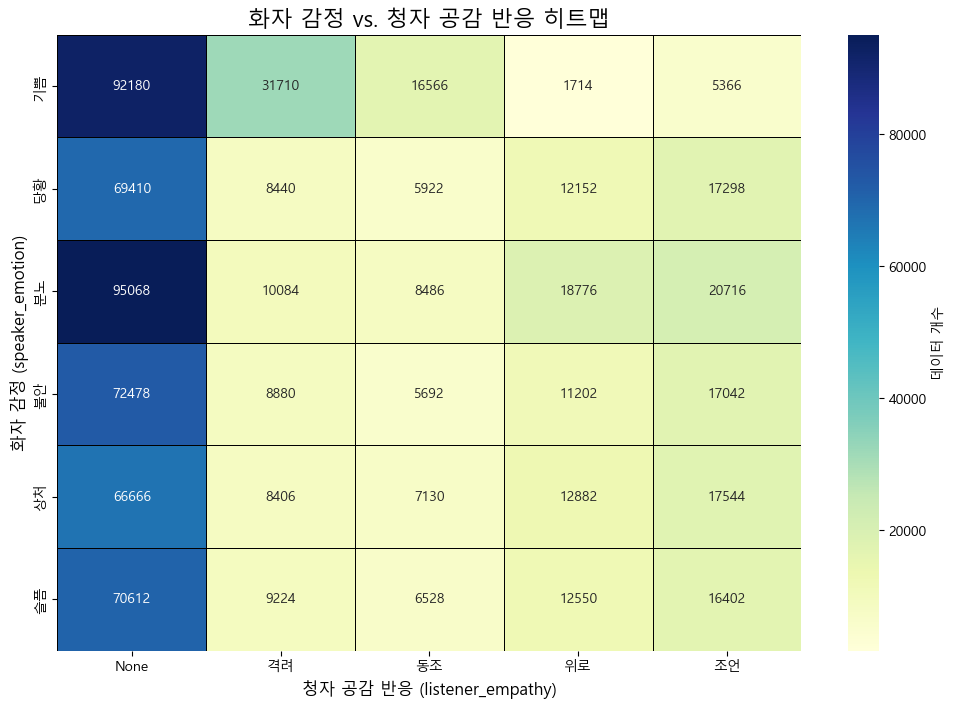


--- 감정별 공감 반응 비율 (%) ---
listener_empathy  None    격려    동조    위로    조언
speaker_emotion                               
기쁨                62.5  21.5  11.2   1.2   3.6
당황                61.3   7.5   5.2  10.7  15.3
분노                62.1   6.6   5.5  12.3  13.5
불안                62.9   7.7   4.9   9.7  14.8
상처                59.2   7.5   6.3  11.4  15.6
슬픔                61.2   8.0   5.7  10.9  14.2


In [33]:
## B. 감정-공감 교차 분석 (히트맵)

# 1. 교차표 생성
# 'speaker_emotion'을 행으로, 'listener_empathy'를 열로 하여 빈도수 계산
crosstab = pd.crosstab(df_all['speaker_emotion'], df_all['listener_empathy'])

# 2. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, 
            annot=True,        # 값 표시
            fmt='d',           # 정수형 포맷
            cmap='YlGnBu',     # 색상 팔레트
            linewidths=.5,     # 셀 경계선
            linecolor='black', # 경계선 색상
            cbar_kws={'label': '데이터 개수'}) 

plt.title('화자 감정 vs. 청자 공감 반응 히트맵', fontsize=16)
plt.xlabel('청자 공감 반응 (listener_empathy)', fontsize=12)
plt.ylabel('화자 감정 (speaker_emotion)', fontsize=12)
plt.show()

# 3. 정규화된 교차표 (비율) 출력 (행 기준으로 100% 합산)
crosstab_norm = pd.crosstab(df_all['speaker_emotion'], df_all['listener_empathy'], normalize='index').mul(100).round(1)
print("\n--- 감정별 공감 반응 비율 (%) ---")
print(crosstab_norm)
# (예시 해석: '슬픔' 행에서 가장 높은 비율을 차지하는 'listener_empathy'가 무엇인지 확인)

# 역할별 텍스트 길이 분석


--- 역할별 평균 텍스트 길이 ---
role
listener    78.4
speaker     70.8
Name: text_length, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_17012\1143882243.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='role', y='text_length', data=df_all, palette='pastel')


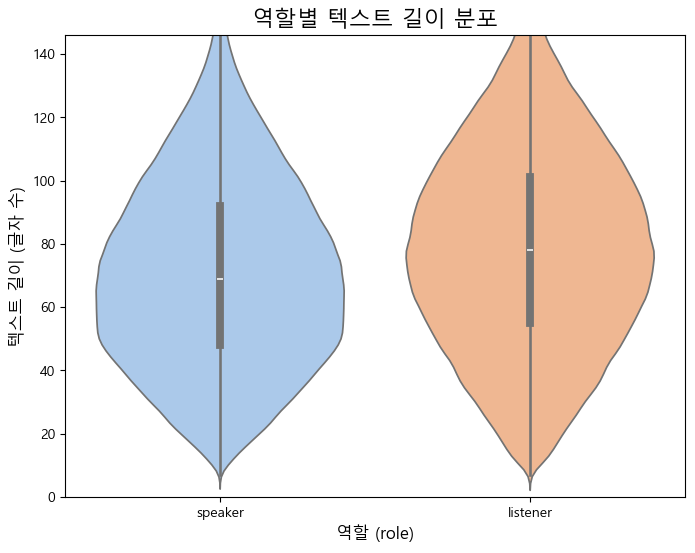

In [34]:
## A. 역할별 텍스트 길이 분석

# 1. 텍스트 길이 컬럼 추가
df_all['text_length'] = df_all['text'].apply(len)

# 2. 역할별 평균 길이 비교
mean_length_by_role = df_all.groupby('role')['text_length'].mean().round(1).sort_values(ascending=False)

print("\n--- 역할별 평균 텍스트 길이 ---")
print(mean_length_by_role)

# 3. 길이 분포 시각화 (Violin Plot 또는 Box Plot)
plt.figure(figsize=(8, 6))
sns.violinplot(x='role', y='text_length', data=df_all, palette='pastel')
plt.title('역할별 텍스트 길이 분포', fontsize=16)
plt.xlabel('역할 (role)', fontsize=12)
plt.ylabel('텍스트 길이 (글자 수)', fontsize=12)
plt.ylim(0, df_all['text_length'].quantile(0.99)) # 극단적인 이상치 제거 후 시각화
plt.show()

# 공감 키워드 빈도 분석


--- 공감 화자 (Listener) 핵심 키워드 (명사) Top 20 ---
마음: 124440회
생각: 87964회
정말: 69558회
자기: 56360회
사람: 56330회
당신: 53620회
감정: 43026회
우리: 40680회
걱정: 35742회
얼마나: 33426회
기분: 30294회
친구: 30242회
엄마: 29860회
지금: 28196회
무슨: 22256회
모습: 21824회
시간: 20662회
상처: 20270회
상황: 19456회
다행: 16648회


C:\Users\user\AppData\Local\Temp\ipykernel_17012\619890661.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words, palette='coolwarm')


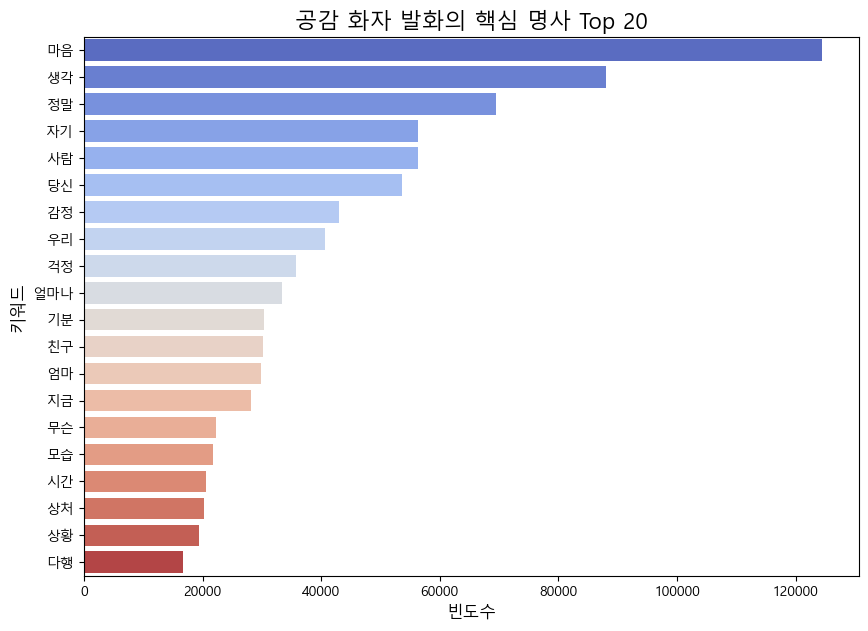

In [35]:
## B. 공감 화자 (Listener)의 핵심 키워드 빈도 분석

# 1. 공감 화자의 텍스트만 필터링
listener_texts = df_all[df_all['role'] == 'listener']['text'].tolist()

# 2. 형태소 분석기 초기화
okt = Okt()

# 3. 명사 추출 및 불용어 제거
keywords = []
# 자주 등장하지만 의미 분석에 방해되는 불용어 리스트 (추가적인 정의 필요)
# 예: 공감화자이므로 '아', '네', '정말', '것' 등은 불용어로 처리
korean_stopwords = ['것', '이', '그', '저', '수', '또', '네', '음', '아', '참', '좀', '막', '잘', '뭐', '거', '와'] 

for text in listener_texts:
    # 명사만 추출
    nouns = okt.nouns(text)
    
    # 한 글자 단어 및 불용어 제거
    filtered_nouns = [n for n in nouns if len(n) > 1 and n not in korean_stopwords]
    keywords.extend(filtered_nouns)

# 4. 빈도 계산
word_counts = Counter(keywords).most_common(20) # 가장 많이 등장한 20개 단어

print("\n--- 공감 화자 (Listener) 핵심 키워드 (명사) Top 20 ---")
for word, count in word_counts:
    print(f"{word}: {count}회")

# 5. 워드 클라우드 또는 막대 그래프 시각화 (여기서는 막대 그래프)
top_words = pd.DataFrame(word_counts, columns=['word', 'count'])

plt.figure(figsize=(10, 7))
sns.barplot(x='count', y='word', data=top_words, palette='coolwarm')
plt.title('공감 화자 발화의 핵심 명사 Top 20', fontsize=16)
plt.xlabel('빈도수', fontsize=12)
plt.ylabel('키워드', fontsize=12)
plt.show()

# 후속 감정 분석

In [36]:
# 1. 턴 번호(turn) 임시 컬럼 생성: dialogue_id 기준으로 순차적인 번호 부여 (0부터 시작)
df_all['turn'] = df_all.groupby('dialogue_id').cumcount()

# 2. 시작 감정 (Start Emotion) 추출: 각 대화 세션의 'turn' 컬럼 중 최솟값 (turn=0)
start_emotions = df_all.loc[df_all.groupby('dialogue_id')['turn'].idxmin()].set_index('dialogue_id')['speaker_emotion'].rename('start_emotion')

# 3. 마지막 감정 (End Emotion) 추출: 각 대화 세션의 'turn' 컬럼 중 최댓값 (가장 마지막 턴)
end_emotions = df_all.loc[df_all.groupby('dialogue_id')['turn'].idxmax()].set_index('dialogue_id')['speaker_emotion'].rename('end_emotion')

# 4. 후속 감정 상태 정의 테이블 생성
emotion_flow_df = pd.concat([start_emotions, end_emotions], axis=1).reset_index(names='dialogue_session_id')


# 5. 후속 감정 레이블링 규칙 적용 (이전과 동일)
def map_result_emotion(row):
    # 시작 감정이 '기쁨'인 경우 (유지/강화되어 레이블링 안 됨)
    if row['start_emotion'] == '기쁨':
        return '기쁨 유지 (규칙 제외)'
    
    # 부정적 감정 해소 성공 케이스
    elif row['end_emotion'] in ['기쁨', '중립']:
        return row['end_emotion']
    
    # 부정적 감정 해소 실패/미완료 (마지막에도 부정적 감정 유지)
    else:
        return '미해결' # 또는 row['end_emotion']

emotion_flow_df['final_result'] = emotion_flow_df.apply(map_result_emotion, axis=1)

print("--- 감정 흐름 분석 테이블 (Top 5) ---")
print(emotion_flow_df.head())

--- 감정 흐름 분석 테이블 (Top 5) ---
  dialogue_session_id start_emotion end_emotion   final_result
0          BE22000001            분노          분노            미해결
1          BE22000002            슬픔          슬픔            미해결
2          BE22000003            슬픔          슬픔            미해결
3          BE22000004            기쁨          기쁨  기쁨 유지 (규칙 제외)
4          BE22000005            분노          분노            미해결


In [37]:
# A. Sankey Diagram용 데이터 준비
sankey_data = emotion_flow_df.groupby(['start_emotion', 'final_result']).size().reset_index(name='count')
sankey_data_for_viz = sankey_data[sankey_data['final_result'] != '기쁨 유지 (규칙 제외)']

print("\n--- Sankey Diagram 데이터 (부정 감정 해소 집중) ---")
print(sankey_data_for_viz.sort_values(by='count', ascending=False).head(10))

# B. Grouped Bar Chart용 데이터 준비
negative_emotions_df = emotion_flow_df[emotion_flow_df['start_emotion'] != '기쁨']
bar_chart_data = negative_emotions_df.groupby('start_emotion')['final_result'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

print("\n--- Grouped Bar Chart 데이터 (부정 감정별 해소 비율) ---")
print(bar_chart_data)


--- Sankey Diagram 데이터 (부정 감정 해소 집중) ---
  start_emotion final_result  count
2            분노          미해결   5133
3            불안          미해결   3849
5            슬픔          미해결   3848
1            당황          미해결   3828
4            상처          미해결   3793

--- Grouped Bar Chart 데이터 (부정 감정별 해소 비율) ---
  start_emotion final_result  percentage
0            당황          미해결       100.0
1            분노          미해결       100.0
2            불안          미해결       100.0
3            상처          미해결       100.0
4            슬픔          미해결       100.0


# 공감 반응별 감정 해소 성공률 분석

In [38]:
# 1. 각 대화 세션의 마지막 턴(turn)에서 나타난 공감 반응(listener_empathy) 추출
# 'turn' 컬럼이 아직 없으면 다시 생성 (이전 단계에서 사용했던 cumcount 방식)
if 'turn' not in df_all.columns:
    df_all['turn'] = df_all.groupby('dialogue_id').cumcount()

# 각 세션의 최대 'turn' 값을 가진 행에서 'listener_empathy' 추출
final_empathy = df_all.loc[df_all.groupby('dialogue_id')['turn'].idxmax()].set_index('dialogue_id')['listener_empathy'].rename('final_empathy_type')

# 2. 감정 흐름 분석 테이블과 최종 공감 반응 결합
# 'dialogue_id' (emotion_flow_df에서는 'dialogue_session_id')를 기준으로 결합
flow_with_empathy_df = emotion_flow_df.set_index('dialogue_session_id').join(final_empathy).reset_index()

# 시작 감정이 '기쁨'인 데이터(규칙 제외)와 'None' 공감 반응 데이터는 분석에서 제외 (부정 감정 해소 집중)
analysis_df = flow_with_empathy_df[
    (flow_with_empathy_df['start_emotion'] != '기쁨') & 
    (flow_with_empathy_df['final_empathy_type'] != 'None')
].copy()


# 3. 해소 성공 여부 컬럼 생성
# '기쁨' 또는 '중립'이면 성공(True), '미해결'이면 실패(False)
analysis_df['success'] = analysis_df['final_result'].isin(['기쁨', '중립'])

print("--- 결합된 분석 테이블 (Top 5) ---")
print(analysis_df[['dialogue_session_id', 'start_emotion', 'final_empathy_type', 'final_result', 'success']].head())

--- 결합된 분석 테이블 (Top 5) ---
    dialogue_session_id start_emotion final_empathy_type final_result  success
101          BE22000102            당황                 조언          미해결    False
113          BE22000114            분노                 조언          미해결    False
116          BE22000117            불안                 조언          미해결    False
226          BE22000227            분노                 격려          미해결    False
264          BE22000265            슬픔                 동조          미해결    False



--- 공감 반응별 감정 해소 성공률 (%) ---
  final_empathy_type  success_rate
0                 격려           0.0
1                 동조           0.0
2                 위로           0.0
3                 조언           0.0


C:\Users\user\AppData\Local\Temp\ipykernel_17012\22151776.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='final_empathy_type', y='success_rate', data=empathy_success_rate, palette='plasma')


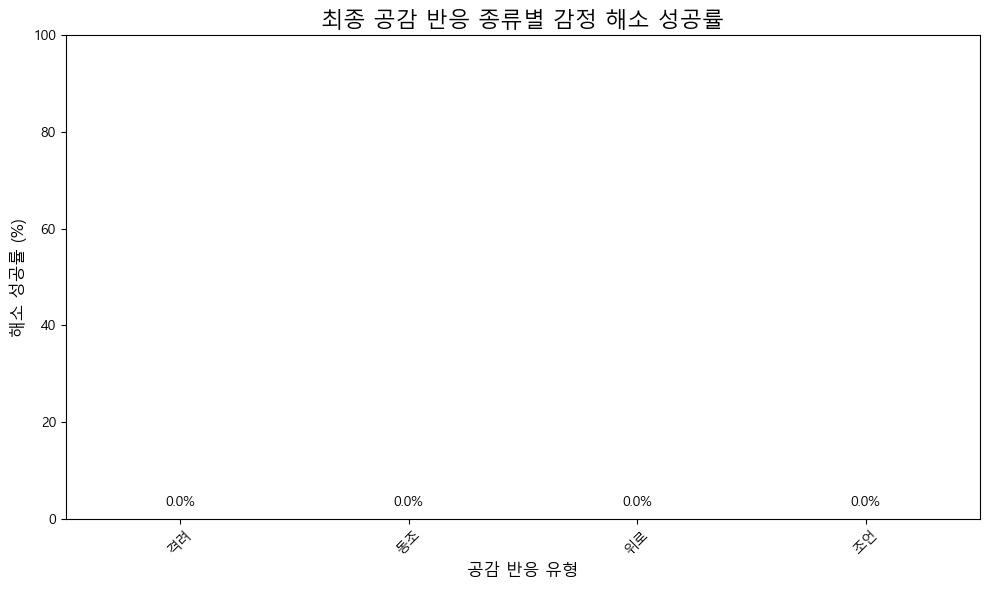

In [39]:
# Matplotlib 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

# 1. 공감 반응별 성공률 계산
empathy_success_rate = analysis_df.groupby('final_empathy_type')['success'].mean().mul(100).sort_values(ascending=False).reset_index(name='success_rate')

print("\n--- 공감 반응별 감정 해소 성공률 (%) ---")
print(empathy_success_rate)


# 2. 막대 그래프 시각화 
plt.figure(figsize=(10, 6))
sns.barplot(x='final_empathy_type', y='success_rate', data=empathy_success_rate, palette='plasma')

plt.title('최종 공감 반응 종류별 감정 해소 성공률', fontsize=16)
plt.xlabel('공감 반응 유형', fontsize=12)
plt.ylabel('해소 성공률 (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)

# 각 막대 위에 성공률 값 표시
for index, row in empathy_success_rate.iterrows():
    plt.text(index, row['success_rate'] + 2, f"{row['success_rate']:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [40]:
# 부정적 감정 목록 (데이터셋의 실제 감정 종류에 맞게 조정 필요)
# 데이터셋의 모든 부정적 감정 레이블을 포함해야 합니다.
NEGATIVE_EMOTIONS = ['슬픔', '분노', '불안', '당황', '상처'] 

# 5. 후속 감정 레이블링 규칙 적용 (수정됨)
def map_result_emotion_fixed(row):
    # 1. 시작 감정이 '기쁨'인 경우 (유지/강화)
    if row['start_emotion'] == '기쁨':
        return '기쁨 유지 (규칙 제외)'
    
    # --- 시작 감정이 부정적(NEGATIVE_EMOTIONS에 포함)인 경우 ---
    
    # 2. 명시적으로 '기쁨'으로 해소 성공한 케이스
    elif row['end_emotion'] == '기쁨':
        return '기쁨'
    
    # 3. 마지막 감정(end_emotion)이 부정적 감정 목록에 포함되지 않은 경우 -> '중립'으로 해소 성공으로 간주
    elif row['end_emotion'] not in NEGATIVE_EMOTIONS:
        # 이 조건에 해당하면 '중립' 또는 기타 비-부정적 감정 상태로 전환된 것으로 해석합니다.
        return '중립'
    
    # 4. 마지막 감정이 여전히 부정적 감정 목록에 포함된 경우 -> 해소 실패
    else:
        return '미해결' 

emotion_flow_df['final_result'] = emotion_flow_df.apply(map_result_emotion_fixed, axis=1)

print("--- 수정된 감정 흐름 분석 테이블 (Top 5) ---")
print(emotion_flow_df.head())

--- 수정된 감정 흐름 분석 테이블 (Top 5) ---
  dialogue_session_id start_emotion end_emotion   final_result
0          BE22000001            분노          분노            미해결
1          BE22000002            슬픔          슬픔            미해결
2          BE22000003            슬픔          슬픔            미해결
3          BE22000004            기쁨          기쁨  기쁨 유지 (규칙 제외)
4          BE22000005            분노          분노            미해결


In [41]:
# 3. 공감 반응별 감정 해소 성공률 분석 코드 재실행

# 시작 감정이 '기쁨'인 데이터(규칙 제외)와 'None' 공감 반응 데이터는 분석에서 제외 
analysis_df = flow_with_empathy_df[
    (flow_with_empathy_df['start_emotion'] != '기쁨') & 
    (flow_with_empathy_df['final_empathy_type'] != 'None')
].copy()

# 해소 성공 여부 컬럼 생성
analysis_df['success'] = analysis_df['final_result'].isin(['기쁨', '중립'])

# 공감 반응별 성공률 계산
empathy_success_rate = analysis_df.groupby('final_empathy_type')['success'].mean().mul(100).sort_values(ascending=False).reset_index(name='success_rate')

print("\n--- [수정 후] 공감 반응별 감정 해소 성공률 (%) ---")
print(empathy_success_rate)


--- [수정 후] 공감 반응별 감정 해소 성공률 (%) ---
  final_empathy_type  success_rate
0                 격려           0.0
1                 동조           0.0
2                 위로           0.0
3                 조언           0.0
